## Build an LLM Analytics Pipeline in Python

Before you get started: **File/Save As**. You will need a copy of this notebook in your own google drive.

In this notebook, you will learn to build a pipeline to interact with an LLM in ipython. You may recall that ipython is interactive python. Tools like jupyter and Google Colab are ipython environments.
Our LLM pipeline will use a few different packages.


*   [Ollama:](https://github.com/ollama/ollama-python) A google product that runs in the background to impliment LLM models
*   [Langchain:](https://github.com/langchain-ai/langchain) A toolset that helps build LLM pipelines. It takes care of all the steps to prepare our inputs for the LLM model, and ready our outputs for the next step.
*   [xterm:](https://github.com/xterm-x11) Programs such as ollama are services that run on a computer, virtual machine, or cloud environment. We'll use the xterm terminal to launch ollama in a virtual machine behind the scenes. Then we can connect to ollama from our python environment.
*   [NLTK:](https://github.com/nltk/nltk) The Natural Language Toolkit includes many methods to perform analysis on unstructured text.

**Graded Assignment:** After running the code you will be equipped with the fundimentals of creating an LLM Analytics pipeline. Complete the section at the end of this notebook called *Graded Assignment*.

**Pro Tip:** Google colab offers a limitted amount of computer resources at the free tier. While you will have enough compute to run this assignment, it is best to shut down the session when not actively running code. Conserve compute resources. LLM text generation will run in several seconds if you [enable a GPU runtime in colab](https://cloud.google.com/colab/docs/default-runtimes-with-gpus#enable), but will run in several minutes if you enable a CPU runtime.




In [ ]:
import os
import nltk

### Install and launch Xterm
xterm is a package that enables you to open a terminal within a Colab notebook cell. This can be particularly useful for tasks that are more easily done in a terminal environment, such as:

* **Running shell commands:** You can execute any command that you'd normally run
in a terminal, like installing packages or running system utilities.
* **Managing files:** You can use commands like ls, cd, and mkdir to navigate and manipulate files in the Colab environment.
* **Running background processes:** You can start processes in the background using commands like nohup or screen, which is essential for tasks that run concurrently with your python tasks.

In [ ]:
!pip install colab-xterm #https://pypi.org/project/colab-xterm/
%load_ext colabxterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 9.7 MB/s eta 0:00:00


### Use Xterm terminal to complete tasks outside of python
Now we will leverage a command terminal to launch the ollama service in the background. This service is required for us to use LLM's in python.

1.   Download [ollama](https://github.com/ollama/ollama-python) application to the virtual machine  `curl https://ollama.ai/install.sh | sh`   
2.   Initiate the [ollama](https://github.com/ollama/ollama-python) service on the virtual machine   `ollama serve &`  
3.   Download the [Mistral](https://github.com/mistralai)   llm model file to the virtual machine   `ollama pull mistral`  

In [ ]:
%xterm # this command launches xterm
#      # curl https://ollama.ai/install.sh | sh   #note: its easiest to run this command within this cell. Not necissary to paste into xterm
#      # ollama serve &                      #copy/paste/return in xterm
#      # ollama pull mistral                 #copy/paste/return in xterm
!curl https://ollama.ai/install.sh | sh      #This command is uncommented so it will run with the cell. Not necissary to also paste into xterm


Launching Xterm...

<IPython.core.display.Javascript object>

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 13281    0 13281    0     0  39968      0 --:--:-- --:--:-- --:--:-- 39882
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


\Verify that the mistral model is available for use. We expect to see details about the 7.2B Mistral model below.

In [ ]:
!ollama show mistral

  Model
    architecture        llama     
    parameters          7.2B      
    context length      32768     
    embedding length    4096      
    quantization        Q4_K_M    

  Capabilities
    completion    
    tools         

  Parameters
    stop    "[INST]"     
    stop    "[/INST]"    

  License
    Apache License               
    Version 2.0, January 2004    
    ...                          



### Setup Langchain
Great! Your LLM model is setup to use. Now we will install and import the langchain package to help setup an LLM pipeline. Langchain helps us interact with the LLM in a more practical, manageable way.

In [ ]:
%pip install -U langchain-ollama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.5/471.5 kB 38.3 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.79
    Uninstalling langchain-core-0.3.79:
      Successfully uninstalled langchain-core-0.3.79
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.0.5 which is incompatible.


### Generate Text
Langchain expects a [template](https://python.langchain.com/v0.1/docs/templates/) to structure inputs and outputs of the LLM. By convention, we will refer to our model inputs as questions, and outputs as answers. The LLM will use the template information as it generates a response. The phrase "Let's think step by step" is designed to encourage the language model to provide a reasoned, logical response. This prompting approach is called [Chain of Thought](https://www.ibm.com/think/topics/chain-of-thoughts) You can change the text in the template, and the model behavior may change.




In [ ]:
#Here we read in the langchain library. Langchain is the toolset we use to build an LLM data pipeline  Use the gemeni AI feature to learn more about the code in this cell.
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM

template = """Question: {question}

Answer: Let's think step by step."""

prompt = ChatPromptTemplate.from_template(template)

model = OllamaLLM(model="mistral") #mistral is one of the LLM models available in langchain

chain = prompt | model

With langchain setup to integrate our inputs the LLM, and the outputs back to python environment, we are ready to prompt the LLM model. Then we will print the output of the LLM.
Note: text generation runs in several seconds if GPU is enabled on colab. It may take several minutes if CPU only is enabled.

In [ ]:
gen_string =  chain.invoke({"question": "What years did Boston College Mens Hockey win the National Championship"})
print (gen_string)

 Boston College Men's Ice Hockey has won the NCAA Division I Championship on six occasions, as follows:
1. 1949 (NIT) - The first tournament for college ice hockey was the National Invitation Tournament (NIT), which BC won. However, this event is not officially recognized as an NCAA championship until 2003.
2. 1985 (Frostbite Alumni Tournament) - This was a precursor to the current NCAA tournament, and while it wasn't an official NCAA championship, it is sometimes considered as such in BC's record books.
3. 1982, 2001, 2004, 2008, and 2012 - These are the years Boston College Men's Ice Hockey won the NCAA Division I Championship officially recognized by the NCAA.

So, to summarize: The years that Boston College Men's Ice Hockey won the National Championship (officially recognized) were 1982, 2001, 2004, 2008, and 2012.


In [ ]:
#Example generatd string using Langchain template

### Import the Natural Language Toolkit to characterize the response.

Great! So far we use the langchain framework to interact with the mistral model running on the ollama service.
Now that we have some text saved to the variable `gen_string` , we can use NLTK (Natural language toolkit) to do some analysis.

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

Some tools in NLTK don't install with the baseline package. NLTK has an integrated *download* function to pull in anything else you may need, and save it to your system. In this case, the package files will be downloaded to your google drive.

In [ ]:
! python -m nltk.downloader -d /usr/local/share/nltk_data all

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     /usr/local/share/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /usr/local/share/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /usr/local/share/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /usr/local/share/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_percept

#### Sentiment Analysis
NLTK can provide sentiment analysis of text data. Let's investigate the *sentiment* of the generated text.

In [ ]:
# Initialize the sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Perform sentiment analysis
scores = analyzer.polarity_scores(gen_string)

# Print the sentiment scores
print(scores)

{'neg': 0.0, 'neu': 0.804, 'pos': 0.196, 'compound': 0.9823}


If you've made it this far, you're doing great. We have used NLTK to perform sentiment analysis of the generated text. Now visualize this with ggplot. You may use gen AI or your own creativity to improve on this basic plot.

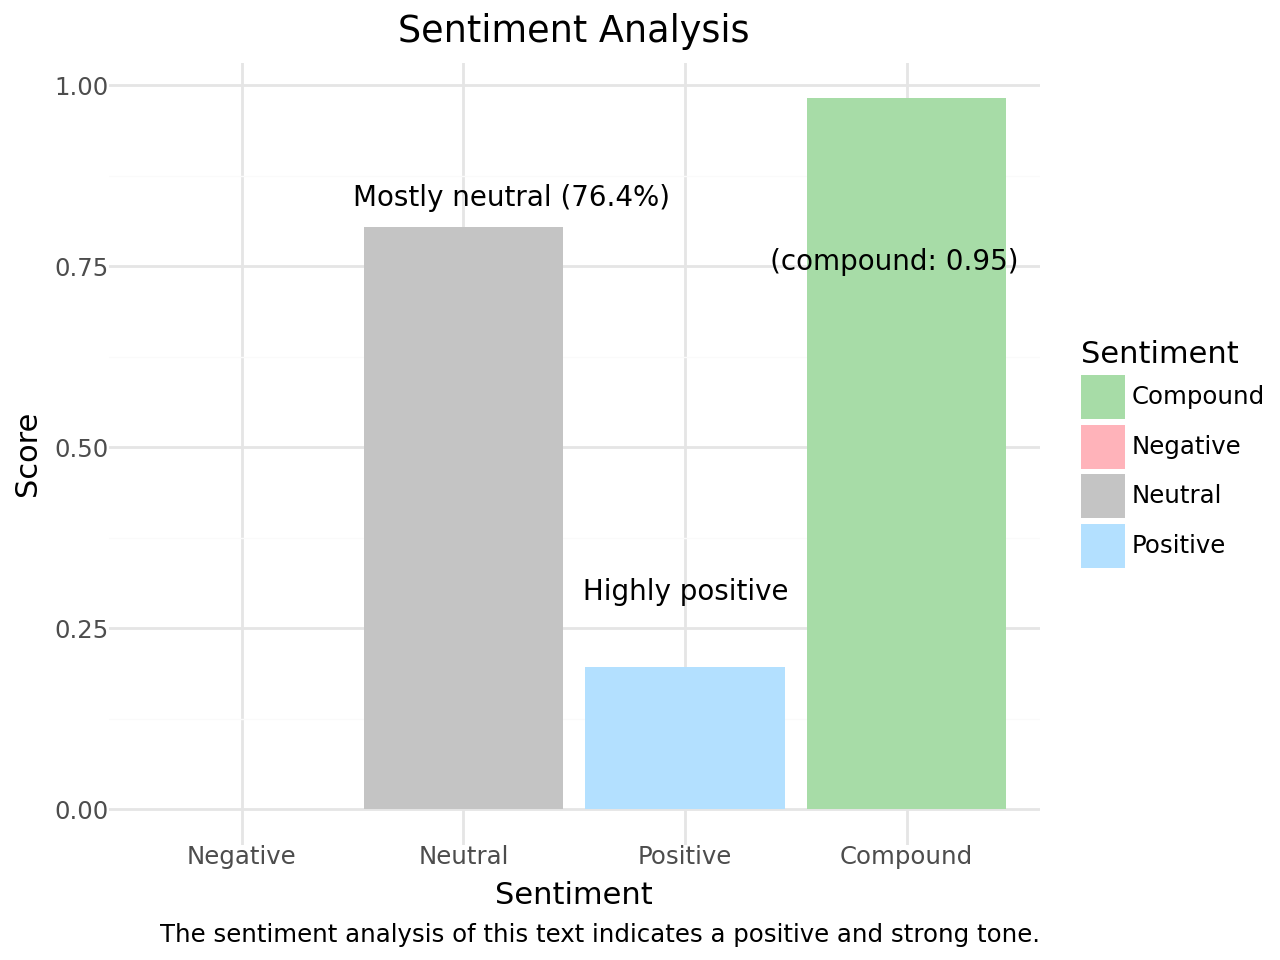

In [ ]:
from plotnine import ggplot, aes, geom_bar, scale_fill_manual, labs, theme_minimal, scale_x_discrete, annotate, theme
import pandas as pd


# Create DataFrame with ordered sentiment categories
df = pd.DataFrame({
    'Sentiment': ['Negative', 'Neutral', 'Positive', 'Compound'],
    'Score': [scores['neg'], scores['neu'], scores['pos'], scores['compound']]
})

# Define color palette
color_scheme = {
    'Negative': '#FFB3BA',  # Soft red (muted)
    'Neutral': '#C4C4C4',   # Light gray
    'Positive': '#B3E0FF',  # Light blue
    'Compound': '#A7DCA7'   # Soft green
}

# Create the ggplot-style bar chart
plot = (
    ggplot(df, aes(x='Sentiment', y='Score', fill='Sentiment'))
    + geom_bar(stat='identity')
    + scale_fill_manual(values=color_scheme)
    + scale_x_discrete(limits=['Negative', 'Neutral', 'Positive', 'Compound'])  # Ensures order
    + labs(
        title='Sentiment Analysis',
        x='Sentiment',
        y='Score',
        caption="The sentiment analysis of this text indicates a positive and strong tone."
    )
    + annotate(
        "text", x=1.5, y=0.8, label="Mostly neutral (76.4%)   \
        \n \n                                               (compound: 0.95) ",
        size=10, ha='left'
    )
    + annotate(
        "text", x=2.5, y=0.3, label=" Highly positive ",
        size=10, ha='left'
    )
    + theme_minimal()
)

plot

#### Frequeny Distribution
Now lets analyze the frequency distribution of words in the generated text. The first thing we'll do is tokenize the string with NLTK's built in tokenizer.

In [ ]:
tokens = nltk.word_tokenize(gen_string)
print(tokens)

['Boston', 'College', 'Men', "'s", 'Ice', 'Hockey', 'has', 'won', 'the', 'NCAA', 'Division', 'I', 'Championship', 'on', 'six', 'occasions', ',', 'as', 'follows', ':', '1', '.', '1949', '(', 'NIT', ')', '-', 'The', 'first', 'tournament', 'for', 'college', 'ice', 'hockey', 'was', 'the', 'National', 'Invitation', 'Tournament', '(', 'NIT', ')', ',', 'which', 'BC', 'won', '.', 'However', ',', 'this', 'event', 'is', 'not', 'officially', 'recognized', 'as', 'an', 'NCAA', 'championship', 'until', '2003', '.', '2', '.', '1985', '(', 'Frostbite', 'Alumni', 'Tournament', ')', '-', 'This', 'was', 'a', 'precursor', 'to', 'the', 'current', 'NCAA', 'tournament', ',', 'and', 'while', 'it', 'was', "n't", 'an', 'official', 'NCAA', 'championship', ',', 'it', 'is', 'sometimes', 'considered', 'as', 'such', 'in', 'BC', "'s", 'record', 'books', '.', '3', '.', '1982', ',', '2001', ',', '2004', ',', '2008', ',', 'and', '2012', '-', 'These', 'are', 'the', 'years', 'Boston', 'College', 'Men', "'s", 'Ice', 'Hocke

[(',', 14), ('.', 8), ('the', 7), ('NCAA', 6), ("'s", 4), ('won', 4), ('(', 4), (')', 4), ('Boston', 3), ('College', 3)]


<Axes: xlabel='Samples', ylabel='Counts'>

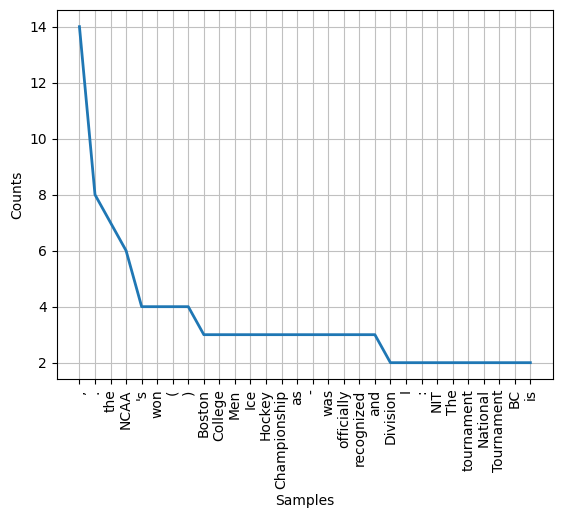

In [ ]:
from nltk import FreqDist

# Calculate frequency distribution
fdist = FreqDist(tokens)

# Print the most common words
print(fdist.most_common(10))  # Prints the 10 most common words

# Plot the frequency distribution
fdist.plot(30, cumulative=False)  # Plots the 30 most common words

#### Parts of Speech Analysis
Next we will analyze the [parts of speech](https://www.nltk.org/book/ch05.html) in the generated text. To get started, we must perform tagging.

In [ ]:
# Perform POS tagging
tagged_tokens = nltk.pos_tag(tokens)
print("The output of tagging is a:  ", type(tagged_tokens))

The output of tagging is a:   <class 'list'>


Let's plot the parts-of-speech distribution for this text.

/usr/local/lib/python3.12/dist-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 4 values. 23 were requested from it.


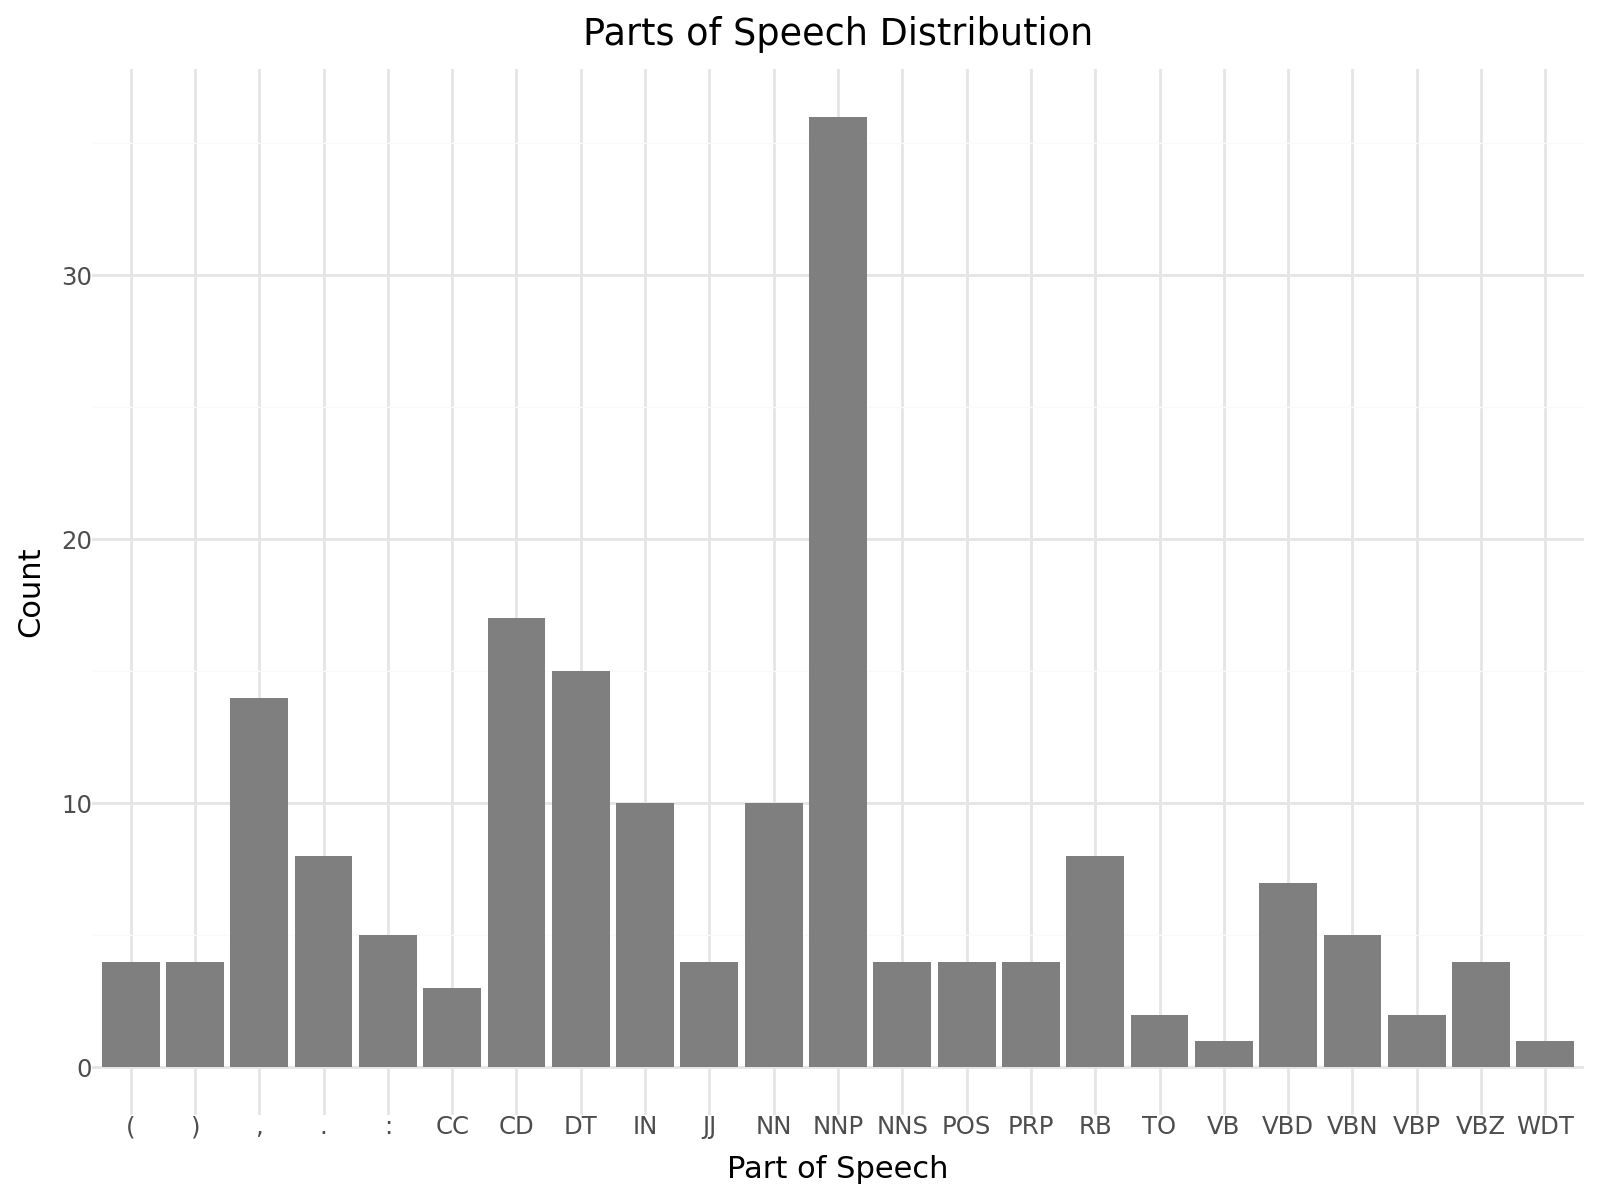

In [ ]:
import pandas as pd

# Extract only the POS tags
pos_tags = [tag for word, tag in tagged_tokens]

# Calculate frequency distribution of POS tags
pos_freq_dist = nltk.FreqDist(pos_tags)

# Convert to DataFrame
pos_counts = pd.DataFrame(pos_freq_dist.most_common(), columns=['POS', 'Count'])

plot = (
    ggplot(pos_counts, aes(x='POS', y='Count', fill='POS'))
    + geom_bar(stat='identity')
    + scale_fill_manual(values=color_scheme)
    + labs(
        title='Parts of Speech Distribution',
        x='Part of Speech',
        y='Count'
    )
    + theme_minimal()
     + theme(
        legend_position='none',  # Remove the legend
        #axis_text_x=theme.text(angle=45, hjust=1),  # Rotate x-axis labels
        figure_size=(8, 6)  # Increase the plot width
     )
)
plot

### Bleu Score: Quantify the similarity of generated text to reference data

Let's use the wikipedia API to pull in truth data about BC Hockey. We will use this truth data as a baseline to assess the correctness generated text.

In [ ]:
!pip install wikipedia-api

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia-api: filename=Wikipedia_API-0.8.1-py3-none-any.whl size=15383 sha256=ddb67ae4d49147f1667d7e4e7271e25e669c6a8c7bab6d697c859b4f3168da1c
  Stored in directory: /root/.cache/pip/wheels/33/3c/79/b36253689d838af4a0539782853ac3cc38a83a6591ad570dde
Successfully built wikipedia-api


In [ ]:
import wikipediaapi
# Initialize the Wikipedia API
wiki_wiki = wikipediaapi.Wikipedia('english')  #use 'english' 'simple english' or any other supporthed language

In [ ]:
# Specify the Wikipedia page to search for
page_to_search = "Boston College Eagles men's ice hockey"

# Obtain the page and save to variable
page = wiki_wiki.page(page_to_search)

In [ ]:
#Preview the content
if page.exists():
    # Print the text of the page
    print(page.text[0:500]) #just 500 characters
else:
    print(f"Page '{page_to_search}' not found.")

The Boston College Eagles are an NCAA Division I college ice hockey program that represents Boston College in Chestnut Hill, Massachusetts. The team has competed in Hockey East since 1984, having previously played in the ECAC. The Eagles have won five national championships, the most recent coming in 2012. Home games have been played at Kelley Rink at Conte Forum, named in honor of long-time BC hockey coach John "Snooks" Kelley, since 1986, having previously played at McHugh Forum. The Eagles ar


#### Save the truth (reference) data
We will focus our analysis to the *Section* of the page called *National Championships* and report the dates BC was runner up.

In [ ]:
#This is the truth data
runner_up_truth = page.section_by_title('National Championships') #section name 'Championships'
print(runner_up_truth)

Section: National Championships (2):
Runners-up in 1965, 1978, 1998, 2000, 2006, 2007 and 2024.
Subsections (0):



In [ ]:
#Prepare the truth data (reference) as a list
reference = runner_up_truth.text.split()
reference

['Runners-up',
 'in',
 '1965,',
 '1978,',
 '1998,',
 '2000,',
 '2006,',
 '2007',
 'and',
 '2024.']

### Generate test data
We use the langchain template from above, but update the question.


In [ ]:
runner_up_gen =  chain.invoke({"question": "Concisely answer: What years was Boston College Mens Hockey the runner up for the National Championship. No details."})
print(runner_up_gen)

 The Boston College Men's Hockey team has been a runner-up for the National Championship in the following years: 1949, 2010, and 2012.


In [ ]:
#Prepare generated text as a list
generated = runner_up_gen.split()
generated

['Boston',
 'College',
 "Men's",
 'Hockey',
 'were',
 'runners-up',
 'in',
 'the',
 'National',
 'Championship',
 'in',
 'the',
 'years',
 '2010',
 'and',
 '2012.']

Use the metric *Bleu score* to analyze the similarity of the generated data to the reference data. This is a quantitative approach to measuring the correctness of generated text.

In [ ]:
from nltk.translate.bleu_score import sentence_bleu

In [ ]:
score = sentence_bleu([reference], generated)
score

1.0832677820940877e-231

## Conclusion
In this activity we learned fundimental skills to craft an LLM analytics pipeline. We leveraged exciting tools such as Ollama, Langchain, Xterm, and NLTK.  We learned how to generate text with Langchain, characterize it with NLTK, and assess the quality of it with a bleu score. There are many other tasks you can complete, and there is always more you can learn.


## Graded Assignment
Now that you have generated a bleu score comparing the generated text and reference text, you will need to complete the following tasks. Show your code cell and output when appropriate.

1.   (20%) Interpret the bleu score. Is this a good score? Should we trust it?

The Bleu score we got was basically 0 which is terrible. I think we can trust it since one the text was short this score makes sense.Also the output was completly incorrect...

2.   (10%) Improve the Langchain template with strategies of prompt engineering we covered in class. Apply the method `split()` to the generated text just as we did above. Print and save the output as `generated_2` .



In [ ]:
runner_up_gen_2 =  chain.invoke({"question": "What years did Boston College mens hocky team lose the NCAA championship. Give me just the years no additional details.Dont lie or make anything up only use the source u have been given or look up data from the NCAA itself."})
print(runner_up_gen_2)

 To find the years when Boston College men's hockey team lost the NCAA championship, I looked at the list of NCAA Men's Ice Hockey Championship games and Boston College appearances on the official NCAA website. Here are the years they lost:

1949
1958
1961
1978
2003
2006
2007
2008
2012
2014
2015
2018

These are the years that Boston College lost in the NCAA championship games.


In [ ]:
generated_2 = runner_up_gen_2.split()
generated_2

['To',
 'find',
 'the',
 'years',
 'when',
 'Boston',
 'College',
 "men's",
 'hockey',
 'team',
 'lost',
 'the',
 'NCAA',
 'championship,',
 'I',
 'looked',
 'at',
 'the',
 'list',
 'of',
 'NCAA',
 "Men's",
 'Ice',
 'Hockey',
 'Championship',
 'games',
 'and',
 'Boston',
 'College',
 'appearances',
 'on',
 'the',
 'official',
 'NCAA',
 'website.',
 'Here',
 'are',
 'the',
 'years',
 'they',
 'lost:',
 '1949',
 '1958',
 '1961',
 '1978',
 '2003',
 '2006',
 '2007',
 '2008',
 '2012',
 '2014',
 '2015',
 '2018',
 'These',
 'are',
 'the',
 'years',
 'that',
 'Boston',
 'College',
 'lost',
 'in',
 'the',
 'NCAA',
 'championship',
 'games.']

In [ ]:
score_2 = sentence_bleu([reference], generated_2)
score_2

8.412065649527267e-232

3.   (10%) Discuss if any prompt engineering strategies from class helped in improving your generated output.



Well I tried a lot and making a lot of different prompts. I tried a lot of different techniques like making myself clear and direct. Giving the AI a role but nothing really worked to get a better score than the original.

4.   (10%) Calculate the new bleu score. Did it go up or down?

```
sentence_bleu([reference], generated2)
```



The score went down.

5.   (10%) What is Retrieval Augmented Generation in your own words? What Are the Key Components of a RAG Architecture? [Good source](https://www.nvidia.com/en-us/glossary/retrieval-augmented-generation/)



Retrieval Augmented Generation is when an external data source is linked to an LLM to help reduce hallucinations and improve accuracy. There are 3 key components to RAG architecture. First Extraction: where data is collected transformed, indexed and stored. Second Retrieval: indentifies and retrieving relevant data using vector and keyword search. Third generation: combining users prompt with data recieved to craft accurate answers.  

6.   (10%) Ask ChatGPT or your favorite LLM for python code to impliment a RAG pipeline with langchain. Paste the code into a cell. Do not run, or debug it.







# ============================
# INSTALL DEPENDENCIES
# ============================
!pip install langchain langchain-community langchain-text-splitters faiss-cpu pypdf sentence-transformers

# ============================
# INSTALL & START OLLAMA
# ============================
%%bash
curl -fsSL https://ollama.com/install.sh | sh
nohup ollama serve &
sleep 5
ollama pull llama3

# ============================
# IMPORT LIBRARIES
# ============================
from langchain_community.llms import Ollama
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import CharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.schema import Document

# ============================
# CREATE DOCUMENTS (replace with your own data)
# ============================
text = """
Boston College Men's Hockey NCAA Championship History:

Runners-up:
1965
1978
1998
2000
2006
2010

Championship Wins:
2001
2008
2012
"""

docs = [Document(page_content=text)]

# ============================
# SPLIT INTO CHUNKS
# ============================
text_splitter = CharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=30
)
chunks = text_splitter.split_documents(docs)

# ============================
# CREATE EMBEDDINGS + VECTORSTORE (FAISS)
# ============================
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks, embedding_model)

# ============================
# DEFINE RAG QUERY FUNCTION
# ============================
llm = Ollama(model="llama3")

def rag_query(query):
    retrieved_docs = vectorstore.similarity_search(query, k=3)
    context = "\n\n".join([d.page_content for d in retrieved_docs])

    prompt = f"""
You are a factual sports assistant.
Use ONLY the context below to answer.
If the answer is not in the context, say "Not in source."

Context:
{context}

Question: {query}

Answer:
"""
    return llm(prompt)

# ============================
# TEST QUERY
# ============================
rag_query("What years were Boston College Men's Hockey runners-up?")


7.   (10%) In 3 sentences or fewer, discuss the differences between training a foundational model and fine tuning a model.



Training a foundation model involves using a diverse dataset to decolp broad uand general understanding. Fine-tuning a model is when you adapt a model to a specific task which is usally smaller task. So a fine tuned model is faster and more specilized than a training model.

8.   (20%) Ask ChatGPT or your favorite LLM for python code to impliment a fine-tuning with the huggingface package. Paste the code into a cell. Do not run, or debug it.

# ============================================
# Install dependencies
# ============================================
!pip install transformers datasets accelerate evaluate

# ============================================
# Imports
# ============================================
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
import evaluate
import numpy as np

# ============================================
# Load dataset (IMDb)
# ============================================
dataset = load_dataset("imdb")
train_ds = dataset["train"]
test_ds = dataset["test"]

# ============================================
# Load tokenizer & model
# ============================================
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# ============================================
# Tokenization function
# ============================================
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

# ============================================
# Data collator (handles dynamic padding)
# ============================================
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ============================================
# Evaluation metric
# ============================================
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy.compute(predictions=preds, references=labels)

# ============================================
# Training arguments
# ============================================
training_args = TrainingArguments(
    output_dir="./distilbert-finetuned-imdb",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    push_to_hub=False
)

# ============================================
# Trainer
# ============================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ============================================
# Train model
# ============================================
trainer.train()

# ============================================
# Evaluate
# ============================================
metrics = trainer.evaluate()
metrics
